## Introduction

### 5 examples of the application of ML in life, benefits
1. Recommendation systems - Enchances user experience by persoanalizing suggestions, increases engagement and sales;
2. Spam Email Filtering - Automates spam detection with high accuracy;
3. Fraud Detection in Banking - Minimizes financial losses, enhances security;
4. Medical Diagnosis Assistance - Improves diagnostic speed and accuracy, reduces human errors;
5. Autonomous Vehicles - Increases road safety, reduces traffic accidents caused by human errors.

### Tasks classificitation
| # | Task                                                                 | Classification Type                          |
|---|----------------------------------------------------------------------|----------------------------------------------|
| 1 | Recommendation systems                                               | Ranking / Regression / Classification        |
| 2 | Spam Email Filtering                                                 | Binary Classification                    |
| 3 | Fraud Detection in Banking                                           | Binary Classification                    |
| 4 | Medical Diagnosis Assistance                                         | Binary / Multiclass Classification       |
| 5 | Autonomous Vehicles                                                  | Classification + Regression              |
| 6 | Predict house price                                                  | Regression                               |
| 7 | Predict whether a client returns a loan                              | Binary Classification                    |
| 8 | Predict when a patient needs to take medicine                        | Regression |
| 9 | Choose what medicine a patient should take                           | Multiclass Classification |
|10 | Choose segment of clients for a promo communication                  | Multiclass Classification                |
|11 | Recognition of defective products on the production line (photo)     | Binary Classification                    |
|12 | Decide how to place products on a shelf in a store                   | Classification (or Regression if predicting profit) |
|13 | Search sites for input text query                                    | Regression                               |
|14 | Split customers into segments to understand behavior                 | Clustering                               |
|15 | Detect anomaly in site traffic                                       | Binary Classification                        |

### Difference between multiclass and multilabel
If one item can belong to more than one class at the same time - is multilabel, owerwise is multiclass.
### Is predicting house price a regression or classification problem?
By deafult: Regression.
1. The target price is real-values quantity;
2. We want to estimate the exact vlaue or a range near the true price.

We can reduce regresssion to classification by divide to discrete intervals ($100k, $200k, $300k) or ("affordable", "mid-range", "luxury").


## Introduction to Data Analysis


In [371]:
import pandas as pd
import numpy, sklearn, lightgbm, scipy, statsmodels, matplotlib, seaborn
from matplotlib import pyplot as plt

In [372]:
# 1. load data from train.json
train_data = pd.read_json('data/train.json')
# 2. amount of rows and collumns
train_data.shape

(49352, 15)

In [373]:
# 3. list of collumns
train_data.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='str')

Conslusion
> target is 'price'

In [374]:
# 4. table info
train_data.info()
train_data.describe()
train_data.corr(numeric_only=True)

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Conclusion
> There are no empty collumns, 49352 entries, more bathrooms higher price, more bedrooms higher price

In [375]:
# 5. dataframe with only 'bathrooms', 'bedrooms', 'interest_level', 'price'
data = train_data[["bathrooms", "bedrooms", "interest_level", "price"]]

## Statistical Data Analysis

<Axes: xlabel='price', ylabel='Count'>

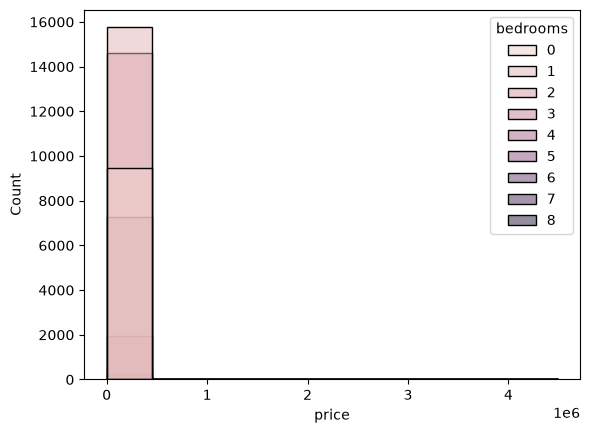

In [376]:
# 1. Histogram
seaborn.histplot(data=data, x='price', hue='bedrooms', bins=10, stat='count')

> Plot is useless. Anything to observe.

<Axes: xlabel='bedrooms', ylabel='price'>

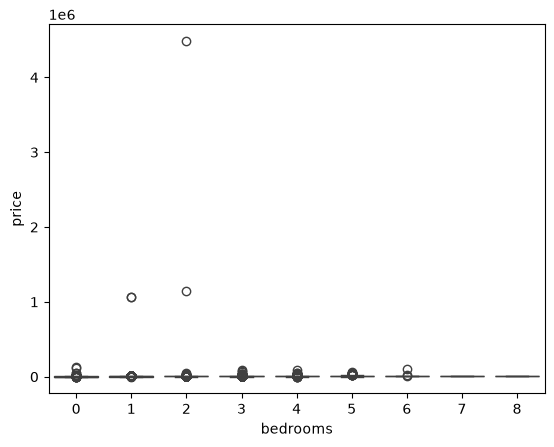

In [377]:
# 2. Boxplot
seaborn.boxplot(data=data, x='bedrooms', y='price')

> There are outliners in price: 4e6 - max, almost 0 - minimum

In [378]:
# 3. Drop < 1 and > 99 percentile rows
lower_bound = data['price'].quantile(0.01)
upper_bound = data['price'].quantile(0.99)
print(f"Bounds: from {lower_bound} to {upper_bound}")
data = data[data['price'].between(lower_bound, upper_bound)]

Bounds: from 1475.0 to 13000.0


<Axes: xlabel='price', ylabel='Count'>

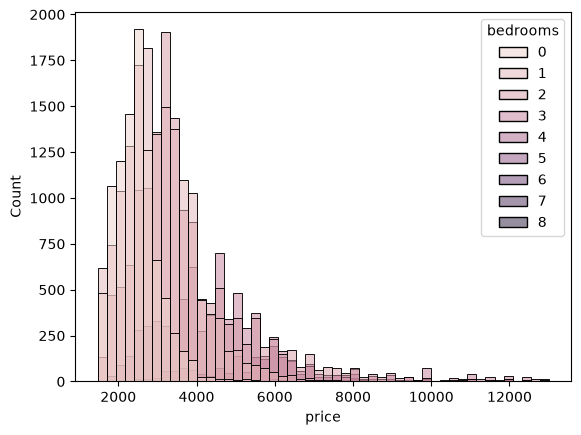

In [379]:
# 4. Histogram again
seaborn.histplot(data=data, x='price', hue='bedrooms', bins=50, stat='count', common_norm=False)

> Without outliners, now plot is usefull. Result: more bedrooms higher price.

In [380]:
# 5. type of interest_level collumn
print(data['interest_level'].dtypes)

str


In [381]:
# 6.1 values in collumn
print(data['interest_level'])
print('--------------')
# 6.2 amount of entries in each category
print(data['interest_level'].value_counts())

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48379, dtype: str
--------------
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64


In [382]:
# 7. encode interest_level values
encoded_values = {'low': 1, 'medium' : 2, 'high': 3}
data['interest_level'] = data['interest_level'].apply(lambda x: encoded_values[x])
data

,bathrooms,bedrooms,interest_level,price
4,1.0,1,2,2400
6,1.0,2,1,3800
9,1.0,2,2,3495
10,1.5,3,2,3000
15,1.0,0,1,2795
...,...,...,...,...
124000,1.0,3,1,2800
124002,1.0,2,2,2395
124004,1.0,1,2,1850
124008,1.0,2,2,4195


Text(0.5, 1.0, 'Histogram for bathrooms feature')

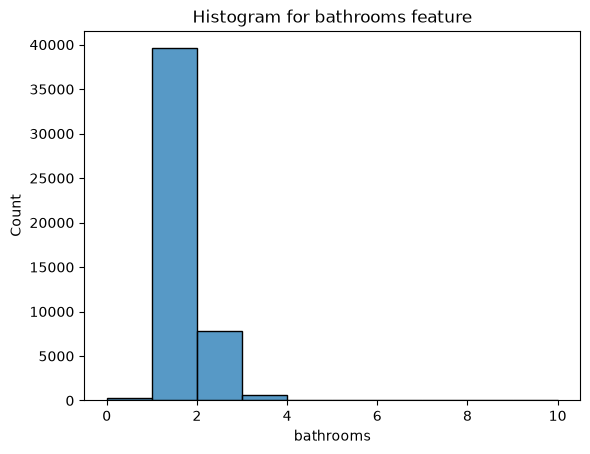

In [383]:
# 8.1 Histogram for bathrooms
seaborn.histplot(data=data, x='bathrooms', bins=10)
plt.title('Histogram for bathrooms feature')

> There are no outliners

Text(0.5, 1.0, 'Histogram for bedrooms feature')

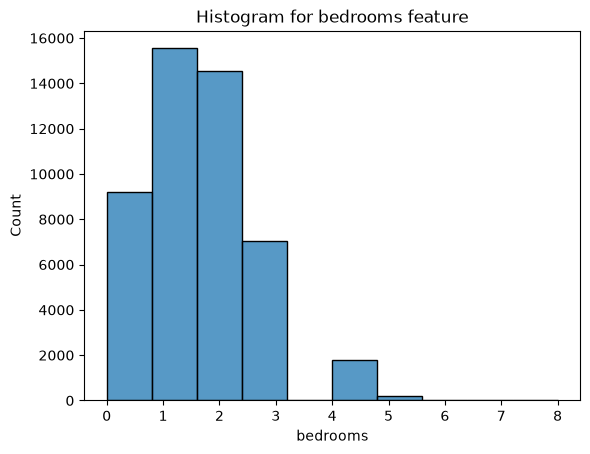

In [384]:
# 8.1 Histogram for bedrooms
seaborn.histplot(data=data, x='bedrooms', bins=10)
plt.title('Histogram for bedrooms feature')

> There are no outliners

In [385]:
# 9. correlation matrix for correlation between features and target.
corr_matrix = data.corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


Text(0.5, 1.0, 'Heat map for correlation matrix')

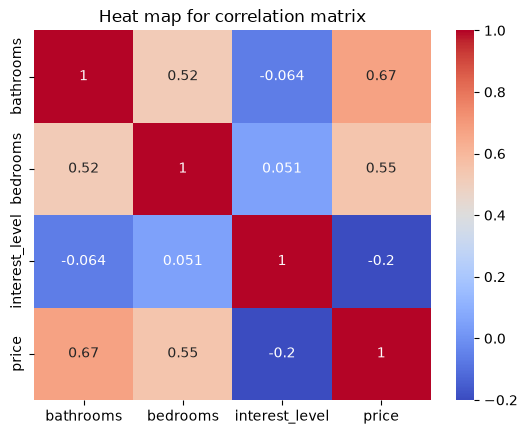

In [386]:
# 10. heat map for the correlation matrix
seaborn.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Heat map for correlation matrix')

> Correlation: more bathrooms higher price, same for bedrooms

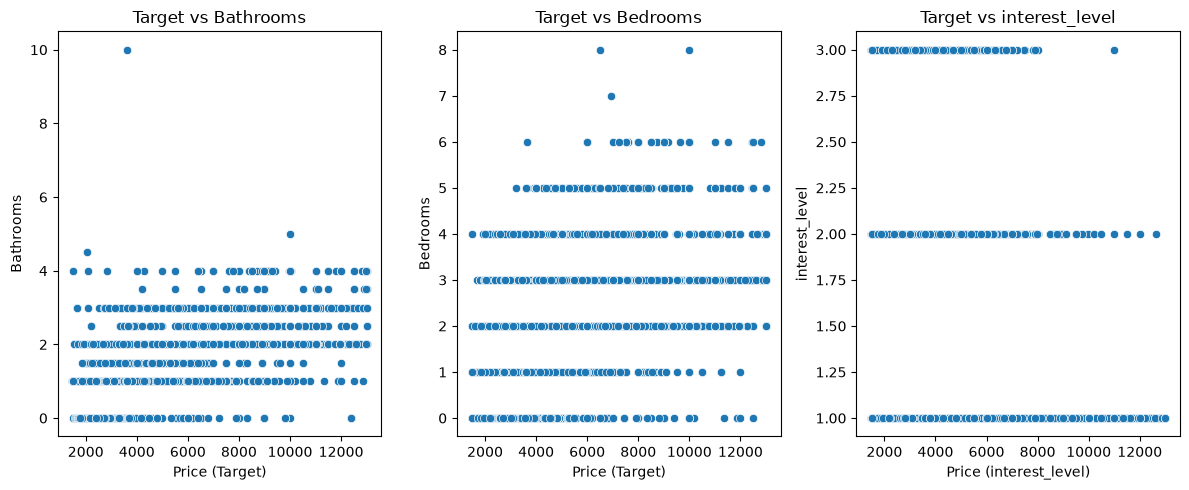

In [387]:
# 11. Scatterplot for correlation between the features and the target

target = 'price'
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
# 11.1 Scatterplot for bathrooms and price
seaborn.scatterplot(data=data, x=target, y='bathrooms', ax=axes[0])
axes[0].set_title('Target vs Bathrooms')
axes[0].set_xlabel('Price (Target)')
axes[0].set_ylabel('Bathrooms')

# 11.2 Scatterplot for bathrooms and price
seaborn.scatterplot(data=data, x=target, y='bedrooms', ax=axes[1])
axes[1].set_title('Target vs Bedrooms')
axes[1].set_xlabel('Price (Target)')
axes[1].set_ylabel('Bedrooms')

# 11.3 Scatterplot for interest_level and price
seaborn.scatterplot(data=data, x=target, y='interest_level', ax=axes[2])
axes[2].set_title('Target vs interest_level')
axes[2].set_xlabel('Price (interest_level)')
axes[2].set_ylabel('interest_level')

plt.tight_layout()
plt.show()

## Creating Features

In [388]:
# 1. Create new features
data['bathrooms_squared'] = data['bathrooms'].apply(lambda x : x**2)
data['bedrooms_squared'] = data['bedrooms'].apply(lambda x : x**2)
data['interest_level_squared'] = data['interest_level'].apply(lambda x : x**2)
# 2. Plot a correlation matrix
data.corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517574,-0.063635,0.671943,0.956023,0.548760,-0.062557
bedrooms,0.517574,1.000000,0.050654,0.545948,0.478817,0.928277,0.046145
interest_level,-0.063635,0.050654,1.000000,-0.200111,-0.068558,0.046340,0.987944
price,0.671943,0.545948,-0.200111,1.000000,0.648486,0.543406,-0.194773
bathrooms_squared,0.956023,0.478817,-0.068558,0.648486,1.000000,0.522227,-0.066568
bedrooms_squared,0.548760,0.928277,0.046340,0.543406,0.522227,1.000000,0.042015
interest_level_squared,-0.062557,0.046145,0.987944,-0.194773,-0.066568,0.042015,1.000000


> squared features more approach zero

In [389]:
# 3. Initialize PolynomialFeatures() with a degree of 10
poly = sklearn.preprocessing.PolynomialFeatures(degree=10, include_bias=True)

# 4. Divide train and test samples
X = data[['bathrooms', 'bedrooms']] # features
Y = data['price'] # target
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=41)

print(X_train.head(3))
print('------')
print(X_test.head(3))
print('------')
print(y_train.head(3))
print('------')
print(y_test.head(3))

       bathrooms  bedrooms
73956        1.0         2
96468        1.0         1
99868        1.0         0
------
       bathrooms  bedrooms
26513        1.0         3
74513        1.0         2
7080         1.0         2
------
73956    2300
96468    4065
99868    2300
Name: price, dtype: int64
------
26513    5400
74513    3195
7080     1800
Name: price, dtype: int64


In [390]:
# 5. Apply PolynomialFeatures() to fit and transform training and test data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# 6. Create df of models results
result_MAE = pd.DataFrame()
result_RMSE = pd.DataFrame()

# 7 Linear Regression model
model = sklearn.linear_model.LinearRegression()
model.fit(X_train_poly, y_train)
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

mae_train = sklearn.metrics.mean_absolute_error(y_train, y_train_pred)
mae_test = sklearn.metrics.mean_absolute_error(y_test, y_test_pred)
rmse_train = numpy.sqrt(sklearn.metrics.mean_squared_error(y_train, y_train_pred))
rmse_test = numpy.sqrt(sklearn.metrics.mean_squared_error(y_test, y_test_pred))

linear_mae = pd.DataFrame({
    'model': ['linear_regression'],
    'mae_train': [mae_train],
    'mae_test': [mae_test]
})
result_MAE = pd.concat([linear_mae, result_MAE])
linear_rmse = pd.DataFrame({
    'model': ['linear_regression'],
    'rmse_train': [rmse_train],
    'rmse_test': [rmse_test]
})
result_RMSE = pd.concat([linear_rmse, result_RMSE])


[3551.3284474  3194.61161251 3194.61161251 ... 5123.46959031 3079.34939992
 3079.34939992]


In [392]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 8. Tree Regressor
tree_model = sklearn.tree.DecisionTreeRegressor(random_state=21)
tree_model.fit(X_train_poly, y_train)

y_train_pred_tree = tree_model.predict(X_train_poly)
y_test_pred_tree = tree_model.predict(X_test_poly)

mae_train_tree = mean_absolute_error(y_train, y_train_pred_tree)
mae_test_tree = mean_absolute_error(y_test, y_test_pred_tree)
rmse_train_tree = numpy.sqrt(mean_squared_error(y_train, y_train_pred_tree))
rmse_test_tree = numpy.sqrt(mean_squared_error(y_test, y_test_pred_tree))

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['decision_tree'],
    'mae_train': [mae_train_tree],
    'mae_test': [mae_test_tree]
})])
result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['decision_tree'],
    'rmse_train': [rmse_train_tree],
    'rmse_test': [rmse_test_tree]
})])

In [393]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 9. Naive models
mean_train = y_train.mean()
median_train = y_train.median()
mean_test = y_test.mean()
median_test = y_test.median()

y_train_pred_mean = numpy.full(y_train.shape, mean_train)
y_test_pred_mean = numpy.full(y_test.shape, mean_test)
y_train_pred_median = numpy.full(y_train.shape, median_train)
y_test_pred_median = numpy.full(y_test.shape, median_test)

# mean
mae_train_mean = mean_absolute_error(y_train, y_train_pred_mean)
mae_test_mean = mean_absolute_error(y_test, y_test_pred_mean)
rmse_train_mean = numpy.sqrt(mean_squared_error(y_train, y_train_pred_mean))
rmse_test_mean = numpy.sqrt(mean_squared_error(y_test, y_test_pred_mean))
# median
mae_train_median = mean_absolute_error(y_train, y_train_pred_median)
mae_test_median = mean_absolute_error(y_test, y_test_pred_median)
rmse_train_median = numpy.sqrt(mean_squared_error(y_train, y_train_pred_median))
rmse_test_median = numpy.sqrt(mean_squared_error(y_test, y_test_pred_median))

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['naive_mean'],
    'mae_train': [mae_train_mean],
    'mae_test': [mae_test_mean]
})])

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['naive_mean'],
    'rmse_train': [rmse_train_mean],
    'rmse_test': [rmse_test_mean]
})])

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['naive_median'],
    'mae_train': [mae_train_median],
    'mae_test': [mae_test_median]
})])

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['naive_median'],
    'rmse_train': [rmse_train_median],
    'rmse_test': [rmse_test_median]
})])

In [395]:
# 10. Print results
print('------- MAE -------')
print(result_MAE)
print('\n------- RMSE -------')
print(result_RMSE)

------- MAE -------
               model    mae_train     mae_test
0  linear_regression   853.497464   899.216932
0      decision_tree   756.573468   755.571516
0         naive_mean  1138.364261  1142.484579
0       naive_median  1085.996899  1087.050434

------- RMSE -------
               model   rmse_train    rmse_test
0  linear_regression  1203.336822  4749.629395
0      decision_tree  1076.193366  1087.756133
0         naive_mean  1597.247636  1599.240677
0       naive_median  1643.944145  1648.268905
